In [27]:
# Goodreads Book Data Analysis - M2: Initial Implementation 


In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [29]:
file = pd.read_csv('Book_Details.csv')
print(file.shape)
file.head()

(16225, 15)


,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['912'],"['Young Adult', 'Fiction', 'Magic', 'Childrens...",3401709,64300,4.50,"{'5': '2,178,760', '4': '856,178', '3': '293,2..."
2,2,3,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Sorcerer's Stone,Harry Potter has no idea how famous he is. Tha...,"['309 pages, Hardcover']","['First published June 26, 1997']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['309'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",10116247,163493,4.47,"{'5': '6,544,542', '4': '2,348,390', '3': '856..."
3,3,5,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Prisoner of Azkaban,"Harry Potter, along with his best friends, Ron...","['435 pages, Mass Market Paperback']","['First published July 8, 1999']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['435'],"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4215031,84959,4.58,"{'5': '2,892,322', '4': '970,190', '3': '287,7..."
4,4,6,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Goblet of Fire,"['652 pages, Paperback']","['734 pages, Paperback']","['First published July 8, 2000']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['734'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3718209,69961,4.57,"{'5': '2,500,070', '4': '899,496', '3': '259,7..."


## Data Preprocessing: 

The following steps were taken to clean and prepared the dataset for analysis. 

In [30]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16225 non-null  int64  
 1   book_id              16225 non-null  int64  
 2   cover_image_uri      16225 non-null  str    
 3   book_title           16225 non-null  str    
 4   book_details         16177 non-null  str    
 5   format               16225 non-null  str    
 6   publication_info     16225 non-null  str    
 7   authorlink           16225 non-null  str    
 8   author               16225 non-null  str    
 9   num_pages            16225 non-null  str    
 10  genres               16225 non-null  str    
 11  num_ratings          16225 non-null  int64  
 12  num_reviews          16225 non-null  int64  
 13  average_rating       16225 non-null  float64
 14  rating_distribution  16225 non-null  str    
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [31]:
file['genres'] = file['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

file['pub_year'] = file['publication_info'].str.extract(r'(\d{4})').astype(float)

file = file[file['pub_year'] >= 1800]

file = file[file['num_ratings'] > 0]

In [32]:
file['num_pages'] = file['num_pages'].str.extract(r'(\d+)').astype(float)

mask = file['num_pages'].isna()
file.loc[mask, 'num_pages'] = file.loc[mask, 'format'].str.extract(r'(\d+)').astype(float)

print(file['num_pages'].isnull().sum())



270


270 books could not be assigned a length category due to missing page count data like Audio CDs and books with no recorded page count. This analysis was verified by comparing the total dataset size against the sum of length bin counts. These books are kept in the dataset but excluded from page length analysis as page count is not meaningful for these formats 

In [33]:
file.describe()

,Unnamed: 0,book_id,num_pages,num_ratings,num_reviews,average_rating,pub_year
count,16021.000000,1.602100e+04,15751.000000,1.602100e+04,16021.000000,16021.000000,16021.000000
mean,8147.903252,1.046377e+07,361.795822,8.574521e+04,5186.320829,4.006694,1992.412646
std,4678.660158,2.154222e+07,253.086746,3.212270e+05,15866.504124,0.317274,30.644640
min,0.000000,1.000000e+00,1.000000,1.000000e+00,0.000000,1.000000,1800.000000
25%,4105.000000,9.654400e+04,242.000000,2.921000e+03,204.000000,3.840000,1985.000000
50%,8173.000000,9.861920e+05,329.000000,1.612800e+04,990.000000,4.030000,2004.000000
75%,12201.000000,1.145459e+07,426.000000,5.583500e+04,3466.000000,4.210000,2010.000000
max,16224.000000,2.096076e+08,8258.000000,1.011625e+07,274695.000000,5.000000,2025.000000


In [34]:
def clean_format(x):
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list) and len(val) > 0:
            raw = val[0]  # e.g. '320 pages, Paperback'
        else:
            return 'Unknown'
    except:
        return 'Unknown'
    
    # Extract just the format type after the comma
    if ',' in raw:
        return raw.split(',')[1].strip()
    elif 'pages' in raw.lower():
        return 'Unknown'  # pages only, no format listed
    else:
        return raw.strip()  # format only, no pages

file['format_type'] = file['format'].apply(clean_format)



def simplify_format(f):
    if 'Kindle' in f or 'ebook' in f.lower() or 'Nook' in f:
        return 'Digital'
    elif 'Audio' in f or 'MP3' in f or 'Cassette' in f:
        return 'Audio'
    elif 'Hardcover' in f or 'Hardback' in f:
        return 'Hardcover'
    elif 'Paperback' in f or 'paperback' in f:
        return 'Paperback'
    else:
        return 'Other'

file['format_type'] = file['format_type'].apply(simplify_format)
print(file['format_type'].value_counts().head(20))

format_type
Paperback    9568
Hardcover    4667
Digital      1541
Other         153
Audio          92
Name: count, dtype: int64


The dataset is primarily physical books - Paperback (9,737) and Hardcover (4,689) make up the majority of books. Digital formats are accounted for only 1,545 entries and Audio only 92 which may limit the strength of format-related association rules. The 'Other' category includes less common formats such as Library Binding, Board Books, Comics, and other miscellaneous formats that did not fit into the four main categories.

The following categorical bins were created to transform contiuous variable into items suitable for FP-Growth association rules 

In [35]:
file['length_bin'] = pd.cut(file['num_pages'],
                            bins=[0, 250, 400, 600, 9000],
                            labels=['Short', 'Medium', 'Long', 'Very Long'])

file['popularity_bin'] = pd.qcut(file['num_ratings'], q=4,
                                 labels=['Niche', 'Moderate', 'Popular', 'Very Popular'])

file['rating_bin'] = pd.cut(file['average_rating'],
                            bins=[0, 3.8, 4.0, 4.2, 5.0],
                            labels=['Low', 'Medium', 'High', 'Very High'])
file['era_bin'] = pd.cut(file['pub_year'], 
                         bins=[1800, 1970, 1980, 1990, 2000, 2010, 2020, 2025],
                         labels=['Classic', '70s', '80s', '90s', '2000s', '2010s', '2020s']
                         )


Four categorical bins were created: length_bin, rating_bin, popularity_bin, and era_bin. These group continues variables into meaningful categories for pattern discovery. 

In [36]:
print(file['length_bin'].value_counts())
print(file['rating_bin'].value_counts())
print(file['popularity_bin'].value_counts())
print(file['format_type'].value_counts())
print(file[file['pub_year'] < 1990]['pub_year'].value_counts().sort_index())


length_bin
Medium       6834
Short        4221
Long         3402
Very Long    1294
Name: count, dtype: int64
rating_bin
High         4439
Very High    4113
Medium       4006
Low          3463
Name: count, dtype: int64
popularity_bin
Niche           4007
Popular         4005
Very Popular    4005
Moderate        4004
Name: count, dtype: int64
format_type
Paperback    9568
Hardcover    4667
Digital      1541
Other         153
Audio          92
Name: count, dtype: int64
pub_year
1800.0      1
1802.0      1
1806.0      1
1807.0      1
1808.0      1
         ... 
1985.0    113
1986.0    133
1987.0    138
1988.0    147
1989.0    140
Name: count, Length: 179, dtype: int64


## Data Summary
The following summary reflects the dataset after all cleaning and the creation of bins have been completed.  

In [37]:
file.describe()

,Unnamed: 0,book_id,num_pages,num_ratings,num_reviews,average_rating,pub_year
count,16021.000000,1.602100e+04,15751.000000,1.602100e+04,16021.000000,16021.000000,16021.000000
mean,8147.903252,1.046377e+07,361.795822,8.574521e+04,5186.320829,4.006694,1992.412646
std,4678.660158,2.154222e+07,253.086746,3.212270e+05,15866.504124,0.317274,30.644640
min,0.000000,1.000000e+00,1.000000,1.000000e+00,0.000000,1.000000,1800.000000
25%,4105.000000,9.654400e+04,242.000000,2.921000e+03,204.000000,3.840000,1985.000000
50%,8173.000000,9.861920e+05,329.000000,1.612800e+04,990.000000,4.030000,2004.000000
75%,12201.000000,1.145459e+07,426.000000,5.583500e+04,3466.000000,4.210000,2010.000000
max,16224.000000,2.096076e+08,8258.000000,1.011625e+07,274695.000000,5.000000,2025.000000


## Exploration
The following visualizations expolore the relationship between book attributes and reader engagement.

Chart 1 - Bar Chart: Average num_ratings by format 

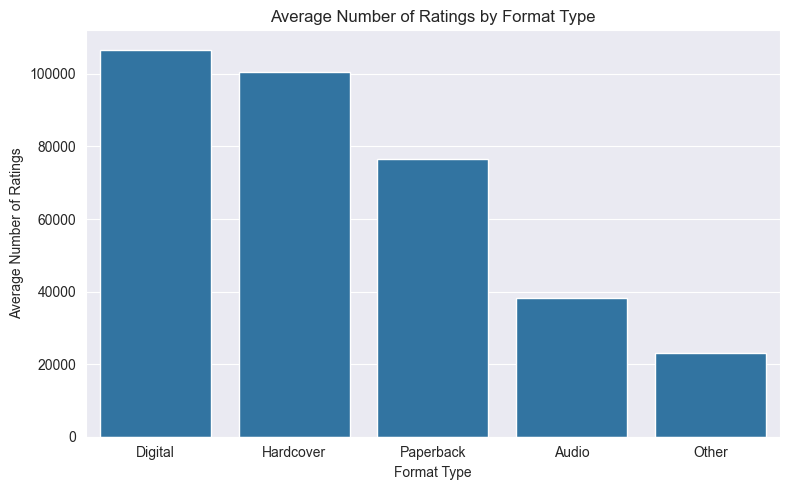

In [38]:
plt.figure(figsize=(8,5))
format_engagement = file.groupby('format_type')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=format_engagement.index, y=format_engagement.values)
plt.title('Average Number of Ratings by Format Type')
plt.xlabel('Format Type')
plt.ylabel('Average Number of Ratings')
plt.tight_layout()
plt.show()

Chart 2 - Boxplot: Distribution of Number of Ratings by Format Type

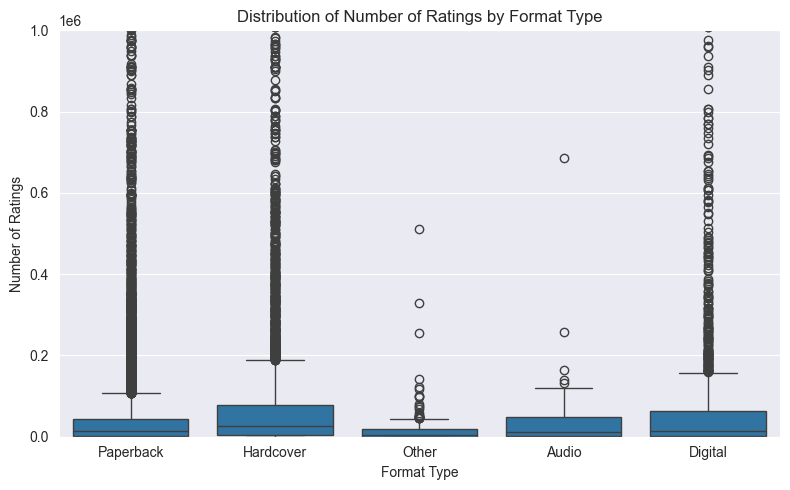

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='format_type', y='num_ratings', data=file)
plt.title('Distribution of Number of Ratings by Format Type')
plt.xlabel('Format Type')
plt.ylabel('Number of Ratings')
plt.ylim(0, 1000000)
plt.tight_layout()
plt.show()

While the bar chart suggested Digital books have the highest average engagement, the boxplot reveals that Hardcover books actually have 
the highest median number of ratings, suggesting that the typical Hardcover book receives more engagement than other formats. Digital's 
high average is driven by a small number of extreme outliers. Audio and Other formats consistently show the lowest engagement across 
the dataset.

Chart 3 - Bar Chart: Average Number of Ratings by Book Length

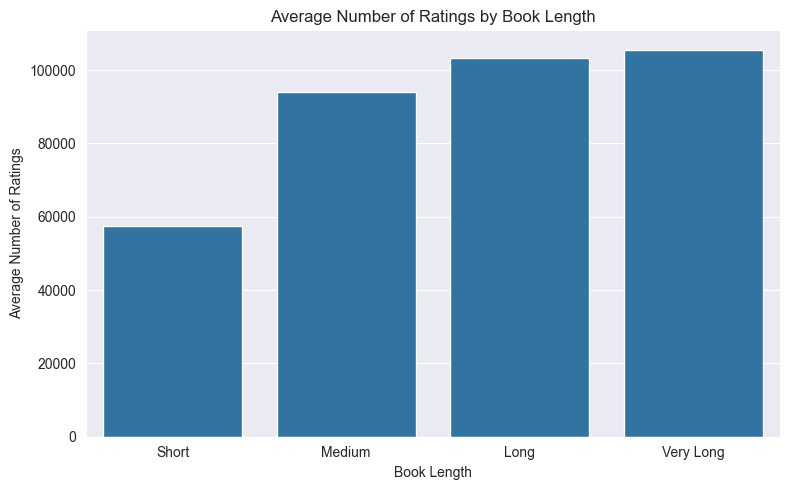

In [40]:
plt.figure(figsize=(8,5))
length_engagement = file.groupby('length_bin')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=length_engagement.index, y=length_engagement.values)
plt.title('Average Number of Ratings by Book Length')
plt.xlabel('Book Length')
plt.ylabel('Average Number of Ratings')
plt.tight_layout()
plt.show()

There is a clear positive relationship between book length and reader engagement. Longer books consistently attract more ratings 
on average, with Very Long books receiving nearly double the average ratings of Short books. This suggests that readers who 
commit to longer books are more likely to engage by leaving a rating. However, this trend may also be influenced by the fact 
that longer books tend to be popular series installments or collected editions which naturally attract more readers.

Chart 4 - Bar Chart: Average Number of Ratings by Genre (Top 10)

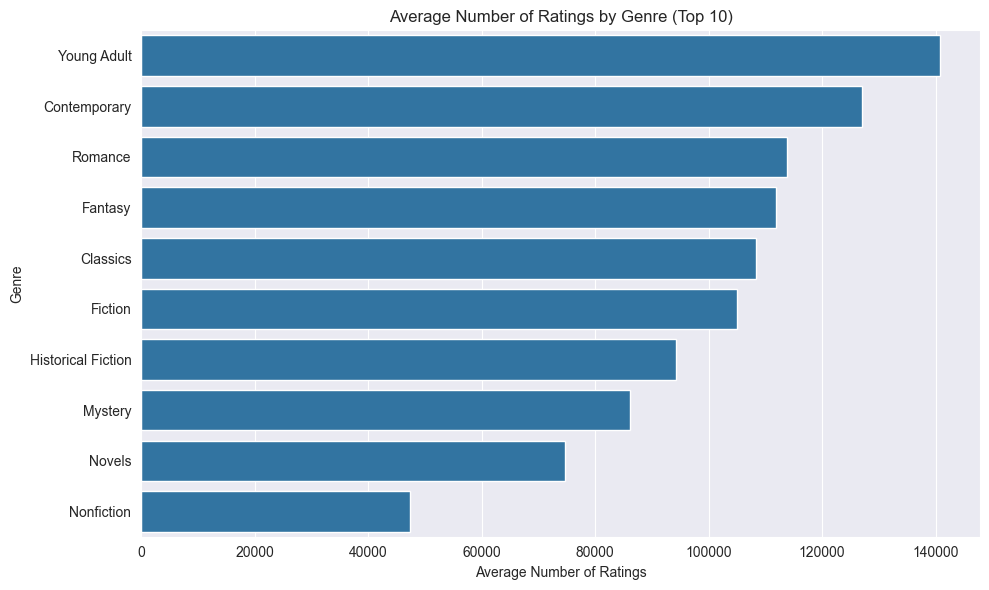

In [41]:
from collections import Counter

# Get top 10 most common genres
all_genres = [genre for sublist in file['genres'] for genre in sublist]
top_genres = [genre for genre, count in Counter(all_genres).most_common(10)]

# Calculate average num_ratings for each top genre
genre_engagement = {}
for genre in top_genres:
    mask = file['genres'].apply(lambda x: genre in x)
    genre_engagement[genre] = file[mask]['num_ratings'].mean()

genre_df = pd.DataFrame(list(genre_engagement.items()), columns=['genre', 'avg_ratings'])
genre_df = genre_df.sort_values('avg_ratings', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='avg_ratings', y='genre', data=genre_df)
plt.title('Average Number of Ratings by Genre (Top 10)')
plt.xlabel('Average Number of Ratings')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

Young Adult books show the highest average reader engagement by a significant margin. This suggests genre 
is a strong predictor of reader engagement, with certain genres naturally attracting more active reader participation than others.  

Note: Books with multiple genres are counted in each of their respective genre groups, meaning a single book can contribute 
to multiple genre averages. This is intentional as the goal is to understand engagement patterns within each genre regardless of overlap.

Chart 5 - Scatter Plot: Number of Ratings vs Average Rating

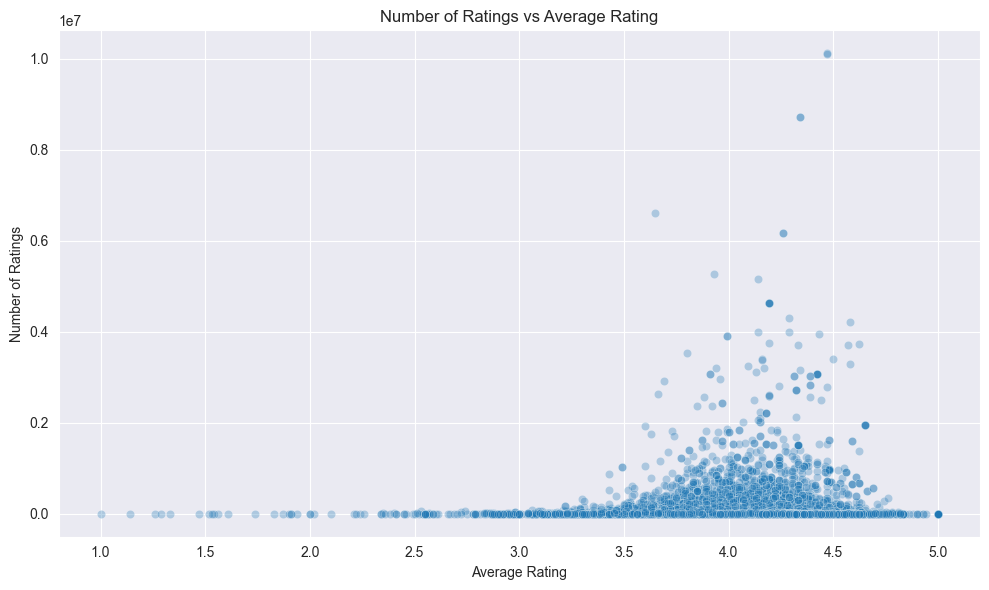

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='average_rating', y='num_ratings', data=file, alpha=0.3)
plt.title('Number of Ratings vs Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

The scatter plot reveals that highly engaged books tend to cluster around average ratings of 4.0-4.5 rather than perfect scores. 
Books with ratings close to 5.0 or below 3.0 generally have very low engagement, suggesting that extremely high ratings may reflect obscure books with few raters rather than genuinely popular titles. This suggests that the optimal range for quality and engagement is an average rating between 4.0 and 4.5.

Chart 6 - Bar Chart: Average Number of Ratings by Publication Era

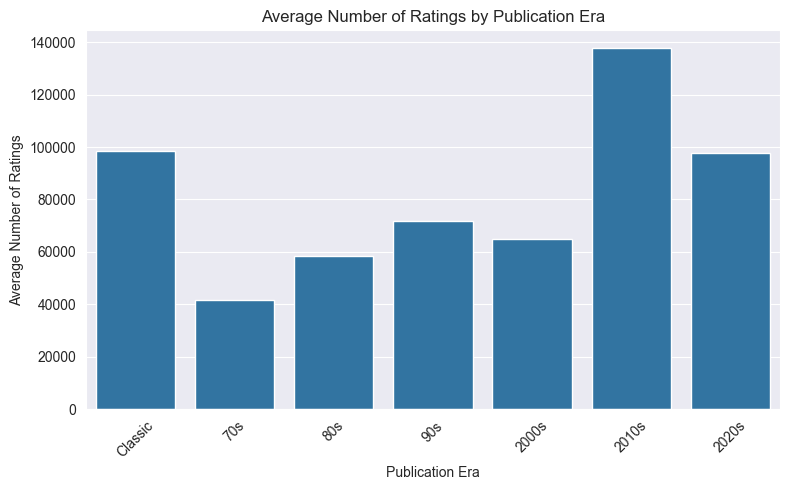

In [43]:
plt.figure(figsize=(8,5))
era_engagement = file.groupby('era_bin')['num_ratings'].mean().sort_values(ascending=False)
sns.barplot(x=era_engagement.index, y=era_engagement.values)
plt.title('Average Number of Ratings by Publication Era')
plt.xlabel('Publication Era')
plt.ylabel('Average Number of Ratings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar graph shows the average number of ratings for books across different publication eras. Books published in the 2010s have the highest average number of ratings, indicating the greatest level of reader engagement. In contrast, books from the 1970s have the lowest average number of ratings. This trend may suggest that the rise of online book communities and digital platforms during the 2010s increased reader participation in rating and reviewing books. It could also indicate that more recently published books receive greater visibility and interaction from modern audiences compared to older publications.

Chart 7 - Count Plot: Book Length vs Popularity Distribution

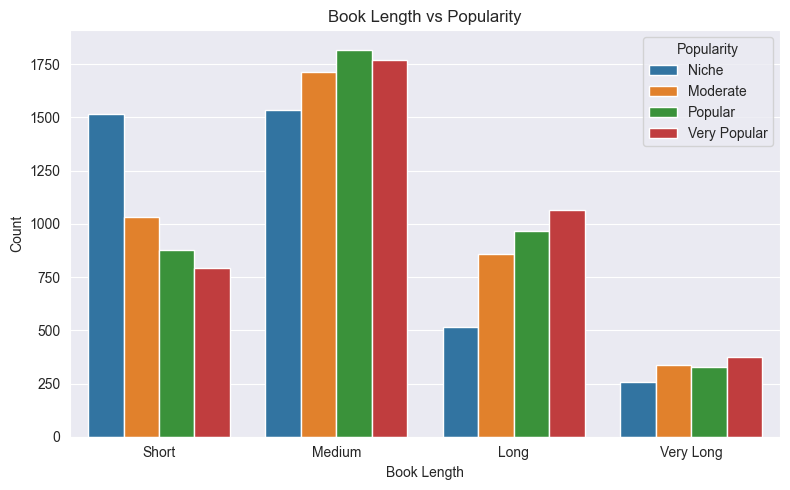

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='length_bin', hue='popularity_bin', data=file)
plt.title('Book Length vs Popularity')
plt.xlabel('Book Length')
plt.ylabel('Count')
plt.legend(title='Popularity')
plt.tight_layout()
plt.show()

The graph compares book length categories with different levels of popularity. Medium-length books appear most frequently across all popularity levels, especially among popular and very popular books. Short books are more common among niche titles but appear less often as popularity increases. Long and very long books become slightly more common as popularity increases, but they still occur less frequently than medium-length books overall. This pattern may suggest that medium-length books are the most appealing to a broad audience. It could also indicate that extremely short or very long books appeal to more specific audiences rather than the general reading population.

In [45]:
print(file[['format_type', 'length_bin', 'rating_bin', 'popularity_bin', 'era_bin']].isnull().sum())

format_type         0
length_bin        270
rating_bin          0
popularity_bin      0
era_bin             1
dtype: int64


## Data Transformation
Each book is treated as a transaction where items represent its attributes including genre, format, length, rating, 
popularity, and publication era. FP-Growth was chosen over Apriori as it is more efficient for larger datasets, avoiding 
the candidate generation step.

In [46]:
from collections import Counter

# Get top 15 most common genres
all_genres = [genre for sublist in file['genres'] for genre in sublist]
top_genres = set([genre for genre, count in Counter(all_genres).most_common(15)])

def make_transaction(row):
    items = []
    
    # Add genres (only top 15)
    for genre in row['genres']:
        if genre in top_genres:
            items.append(f"genre_{genre}")
    
    # Add binned attributes if not null
    if pd.notna(row['format_type']):
        items.append(f"format_{row['format_type']}")
    if pd.notna(row['length_bin']):
        items.append(f"length_{row['length_bin']}")
    if pd.notna(row['rating_bin']):
        items.append(f"rating_{row['rating_bin']}")
    if pd.notna(row['popularity_bin']):
        items.append(f"pop_{row['popularity_bin']}")
    if pd.notna(row['era_bin']):
        items.append(f"era_{row['era_bin']}")
    
    return items

file['transaction'] = file.apply(make_transaction, axis=1)
print(file['transaction'].head(5))

0    [genre_Fantasy, genre_Young Adult, genre_Ficti...
1    [genre_Young Adult, genre_Fiction, genre_Audio...
2    [genre_Fantasy, genre_Fiction, genre_Young Adu...
3    [genre_Fantasy, genre_Fiction, genre_Young Adu...
4    [genre_Fantasy, genre_Young Adult, genre_Ficti...
Name: transaction, dtype: object


In [47]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(file['transaction'])
te_df = pd.DataFrame(te_array, columns=te.columns_)
te_df.index = ['T' + str(i+1) for i in range(len(te_df))] 


print(te_df.shape)
print(te_df.head())

(16021, 39)
    era_2000s  era_2010s  era_2020s  era_70s  era_80s  era_90s  era_Classic  \
T1       True      False      False    False    False    False        False   
T2       True      False      False    False    False    False        False   
T3      False      False      False    False    False     True        False   
T4      False      False      False    False    False     True        False   
T5      False      False      False    False    False     True        False   

    format_Audio  format_Digital  format_Hardcover  ...  length_Short  \
T1         False           False             False  ...         False   
T2         False           False             False  ...         False   
T3         False           False              True  ...         False   
T4         False           False             False  ...         False   
T5         False           False             False  ...         False   

    length_Very Long  pop_Moderate  pop_Niche  pop_Popular  pop_Very Popul

In [48]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Find frequent itemsets
frequent_itemsets = fpgrowth(te_df, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Number of frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.head(20))

Number of frequent itemsets: 411
      support                                      itemsets
0    0.707509                    frozenset({genre_Fiction})
1    0.597216                 frozenset({format_Paperback})
36   0.439611  frozenset({genre_Fiction, format_Paperback})
9    0.426565                    frozenset({length_Medium})
2    0.323014                        frozenset({era_2000s})
3    0.316959                    frozenset({genre_Fantasy})
119  0.295550     frozenset({length_Medium, genre_Fiction})
10   0.291305                 frozenset({format_Hardcover})
20   0.277074                      frozenset({rating_High})
15   0.263467                     frozenset({length_Short})
44   0.263217     frozenset({genre_Fantasy, genre_Fiction})
4    0.256726                 frozenset({rating_Very High})
25   0.250109                        frozenset({pop_Niche})
21   0.250047                    frozenset({rating_Medium})
5    0.249984                 frozenset({pop_Very Popular})
13   0.

In [49]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules = rules.sort_values('lift', ascending=False)

print(f"Number of rules: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Number of rules: 806
                                           antecedents  \
206              frozenset({genre_Historical Fiction})   
203       frozenset({genre_Historical, genre_Fiction})   
575              frozenset({genre_Historical Fiction})   
567  frozenset({genre_Historical, genre_Fiction, fo...   
573  frozenset({genre_Historical Fiction, format_Pa...   
570       frozenset({genre_Historical, genre_Fiction})   
614      frozenset({genre_Classics, genre_Literature})   
617            frozenset({era_Classic, genre_Fiction})   
572  frozenset({genre_Historical Fiction, genre_Fic...   
571    frozenset({genre_Historical, format_Paperback})   
522    frozenset({genre_Historical, format_Paperback})   
525              frozenset({genre_Historical Fiction})   
759         frozenset({era_Classic, genre_Literature})   
758      frozenset({genre_Classics, format_Paperback})   
191              frozenset({genre_Historical Fiction})   
190                      frozenset({genre_Historica

min_support=0.05 was chosen to capture patterns appearing in at least 5% of books while filtering out rare combinations. 
min_threshold=0.3 was chosen to balance rule quantity 
with reliability given the dataset size.

In [50]:
# Filter for rules where the outcome is about engagement
engagement_rules = rules[rules['consequents'].astype(str).str.contains('pop_')]
engagement_rules = engagement_rules.sort_values('lift', ascending=False)

print(f"Number of engagement rules: {len(engagement_rules)}")
print(engagement_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Number of engagement rules: 39
                                        antecedents  \
560     frozenset({genre_Fiction, genre_Audiobook})   
562                    frozenset({genre_Audiobook})   
342                    frozenset({genre_Audiobook})   
454           frozenset({era_2010s, genre_Fiction})   
677           frozenset({genre_Historical Fiction})   
264                          frozenset({era_2010s})   
788                 frozenset({genre_Contemporary})   
389                  frozenset({genre_Young Adult})   
457                          frozenset({era_2010s})   
462       frozenset({genre_Romance, genre_Fiction})   
786  frozenset({genre_Fiction, genre_Contemporary})   
386   frozenset({genre_Fiction, genre_Young Adult})   
327    frozenset({genre_Fiction, format_Hardcover})   
302                         frozenset({rating_Low})   
180                       frozenset({length_Short})   
544                   frozenset({genre_Nonfiction})   
597                 frozenset({gen

In [51]:
very_popular_rules = engagement_rules[
    engagement_rules['consequents'].astype(str) == "frozenset({'pop_Very Popular'})"
]
very_popular_rules = very_popular_rules.sort_values('lift', ascending=False)
print(very_popular_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                        antecedents  \
560     frozenset({genre_Fiction, genre_Audiobook})   
342                    frozenset({genre_Audiobook})   
454           frozenset({era_2010s, genre_Fiction})   
264                          frozenset({era_2010s})   
462       frozenset({genre_Romance, genre_Fiction})   
786  frozenset({genre_Fiction, genre_Contemporary})   
386   frozenset({genre_Fiction, genre_Young Adult})   
327    frozenset({genre_Fiction, format_Hardcover})   
597                 frozenset({genre_Contemporary})   
381         frozenset({rating_High, genre_Fiction})   
325                  frozenset({genre_Young Adult})   
600         frozenset({genre_Fiction, length_Long})   
222       frozenset({genre_Fantasy, genre_Fiction})   
294                      frozenset({genre_Romance})   
801    frozenset({rating_Very High, genre_Fiction})   
182                   frozenset({format_Hardcover})   
158                      frozenset({genre_Fantasy})   
417       

In [52]:
for _, row in very_popular_rules.head(20).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"{{{antecedents}}} → {{{consequents}}}")
    print(f"support = {row['support']:.3f}, confidence = {row['confidence']:.3f}, lift = {row['lift']:.3f}")
    print() 

{genre_Fiction, genre_Audiobook} → {pop_Very Popular}
support = 0.059, confidence = 0.598, lift = 2.393

{genre_Audiobook} → {pop_Very Popular}
support = 0.072, confidence = 0.572, lift = 2.290

{era_2010s, genre_Fiction} → {pop_Very Popular}
support = 0.063, confidence = 0.493, lift = 1.972

{era_2010s} → {pop_Very Popular}
support = 0.083, confidence = 0.408, lift = 1.634

{genre_Romance, genre_Fiction} → {pop_Very Popular}
support = 0.062, confidence = 0.375, lift = 1.499

{genre_Fiction, genre_Contemporary} → {pop_Very Popular}
support = 0.051, confidence = 0.370, lift = 1.478

{genre_Fiction, genre_Young Adult} → {pop_Very Popular}
support = 0.068, confidence = 0.367, lift = 1.469

{genre_Fiction, format_Hardcover} → {pop_Very Popular}
support = 0.075, confidence = 0.366, lift = 1.463

{genre_Contemporary} → {pop_Very Popular}
support = 0.057, confidence = 0.356, lift = 1.425

{rating_High, genre_Fiction} → {pop_Very Popular}
support = 0.068, confidence = 0.350, lift = 1.401

{gen

Audiobook appears as both a genre tag and format type in the Goodreads dataset, reflecting inconsistent categorization by users. The strong association between Audiobook and high engagement holds regardless of whether it is treated as a genre or format attribute.

## Preliminary Findings

FP-Growth identified 19 rules associating book attributes with high reader engagement. The strongest rule found was Audiobook + Fiction (support=0.059, confidence=0.598, lift=2.39), meaning Audiobook Fiction books are 2.4x more likely to be Very Popular than a random book.

Publication era was significant — Fiction books from the 2010s showed nearly 2x higher engagement (lift=1.97). Genre combinations also mattered — Romance Fiction (lift=1.50), Contemporary Fiction (lift=1.48), and Young Adult Fiction (lift=1.47) all associated with higher engagement.

Surprisingly, book length and average rating were weak predictors of engagement, suggesting genre and format matter more than quality or length alone.

Limitations: 
- The dataset is heavily skewed toward Paperback and Hardcover formats which may limit format-related rules. 
- Audiobook appears as both a genre and format tag reflecting inconsistent data categorization.

Next Steps: In M3 anomaly detection will be applied to Q2 to identify books with unusually high or low ratings within 
their genre, and clustering will be applied to Q3 to identify author productivity patterns.